# S19 · Pairs trading, honestly: HDFC Bank vs ICICI Bank

Two big private banks face the same economy, the same RBI interest rates and the same
customers, so their prices tend to move together. Each price alone is hard to predict.
But when the **gap** between them stretches, we can bet it comes back. That is a
**pairs trade**.

We do it honestly: learn everything from **2024** only, then trade **2025**, a year the
rule has never seen.

**New here? Read this once.**

- New to Python? You can still do this whole notebook. Press the play button on each
  cell, top to bottom, and read the plain-English note above each one.
- New to "is this real or just luck"? `primers/hypothesis_testing_and_pvalues.md` is a
  ten-minute, picture-first read.
- Already confident with code or with trading? Look for the cells marked
  **Stretch (optional)** near the end.
- Stuck on a word? It is in `primers/glossary.md`.

## Setup

On **Google Colab**, run the next cell once. On your **own machine** you already
installed everything with `uv`, so it does nothing there.

In [1]:
# This notebook also needs statsmodels, for the cointegration test.
# Colab already ships it, so there is nothing to install.
print("Setup complete - nothing to install.")

Setup complete - nothing to install.


## Step 1 — load the prices

Daily closing prices of HDFC Bank and ICICI Bank on the NSE, January 2019 to December
2025. They were downloaded once with
`yf.download(["HDFCBANK.NS", "ICICIBANK.NS"], start="2019-01-01", end="2026-01-01", auto_adjust=True)`
and saved, so everyone gets exactly the numbers on the slides, with or without internet.

In [2]:
from pathlib import Path
import numpy as np                 # fast maths on lists of numbers
import pandas as pd                # tables of data with dates
import matplotlib.pyplot as plt    # charts

# Where the saved prices live: next to this notebook, or on the course website.
local_copy = Path("../data/hdfc_icici_2019_2025.csv")
website_copy = ("https://girishmkulkarni.github.io/applied-maths-in-industry-site/"
                "sessions/S19/data/hdfc_icici_2019_2025.csv")

if local_copy.exists():
    prices = pd.read_csv(local_copy, index_col=0, parse_dates=True)
else:
    prices = pd.read_csv(website_copy, index_col=0, parse_dates=True)

print("days of prices:", len(prices))
print("from", prices.index[0].date(), "to", prices.index[-1].date())
prices.tail()

days of prices: 1730
from 2019-01-01 to 2025-12-31


,HDFCBANK,ICICIBANK
Date,,
2025-12-24,980.9752,1348.4321
2025-12-26,975.9582,1339.1106
2025-12-29,975.5647,1332.0701
2025-12-30,974.7778,1331.2766
2025-12-31,975.0729,1331.6733


## Step 2 — look at the two banks together

The banks trade at different prices, so we rescale both to start at ₹100 on 1 January
2024 and see whether they drift together.

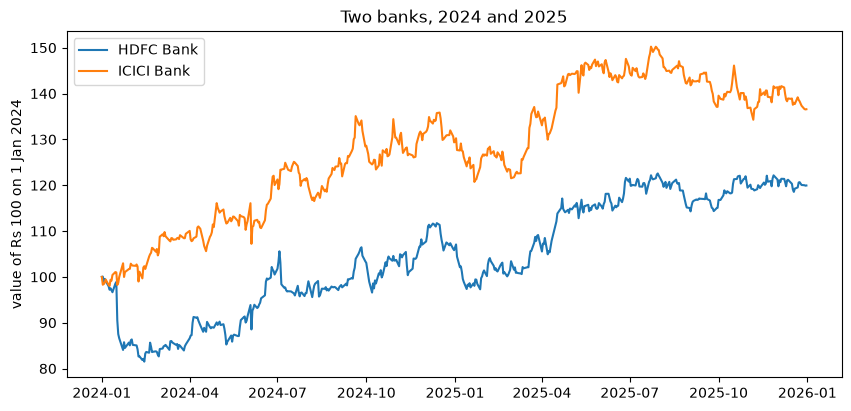

In [3]:
hdfc, icici = prices["HDFCBANK"], prices["ICICIBANK"]
recent = prices.loc["2024":]

plt.figure(figsize=(10, 4.5))
plt.plot(100 * recent["HDFCBANK"] / recent["HDFCBANK"].iloc[0], label="HDFC Bank")
plt.plot(100 * recent["ICICIBANK"] / recent["ICICIBANK"].iloc[0], label="ICICI Bank")
plt.ylabel("value of Rs 100 on 1 Jan 2024")
plt.title("Two banks, 2024 and 2025")
plt.legend()
plt.show()

## Step 3 — build the gap

We cannot just subtract the prices, because the banks trade at different levels. Instead
we fit a straight line **HDFC = a + beta × ICICI** through 2024's prices (the least
squares from S07). The slope **beta** is the **hedge ratio**: owning one HDFC share
against beta ICICI shares is our pair. The **gap** (or **spread**) is

**gap = HDFC − beta × ICICI**

In [4]:
fit = prices.loc["2024"]                      # learn from 2024 only

beta = np.polyfit(fit["ICICIBANK"], fit["HDFCBANK"], 1)[0]
spread = hdfc - beta * icici                  # the gap we trade

print("hedge ratio:", round(beta, 2), "ICICI shares per HDFC share")
print("2024 gap: average", round(spread.loc["2024"].mean()),
      "  typical swing", round(spread.loc["2024"].std()))

hedge ratio: 0.52 ICICI shares per HDFC share
2024 gap: average 182   typical swing 36


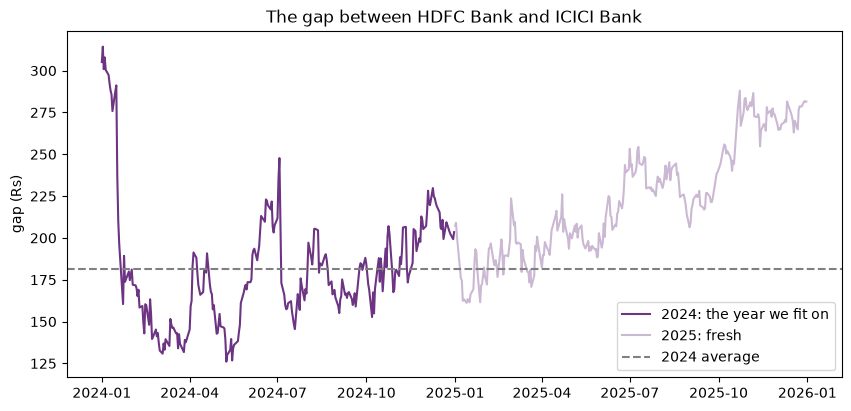

In [5]:
plt.figure(figsize=(10, 4.5))
plt.plot(spread.loc["2024"], color="#6C3483", label="2024: the year we fit on")
plt.plot(spread.loc["2025"], color="#6C3483", alpha=0.35, label="2025: fresh")
plt.axhline(spread.loc["2024"].mean(), color="grey", linestyle="--", label="2024 average")
plt.ylabel("gap (Rs)")
plt.title("The gap between HDFC Bank and ICICI Bank")
plt.legend()
plt.show()

## Step 4 — test the leash (cointegration)

Picture a dog and its owner on a walk. Each wanders anywhere, but the leash keeps the
gap between them steady. Two prices that wander, with a gap that keeps coming back, are
called **cointegrated**.

Our eyes can be fooled, so we test it. `coint` (the Engle–Granger test) asks whether the
gap keeps returning to its average. A **small p-value** (below 0.05) says yes. We test
two different years.

In [6]:
from statsmodels.tsa.stattools import coint

for year in ["2021", "2024"]:
    part = prices.loc[year]
    p = coint(part["HDFCBANK"], part["ICICIBANK"])[1]
    print(year, "p-value:", round(p, 3))      # small p: the leash holds

2021 p-value: 0.389
2024 p-value: 0.024


2024 passes; 2021 does not. Leashes come and go: mergers (HDFC Bank merged with HDFC
Ltd in July 2023), different loan books and different management move banks apart.
So we always re-test.

## Step 5 — the z-score: how unusual is today's gap?

The **z-score** measures the gap in "typical swings" from normal:

**z = (gap − 2024 average) ÷ 2024 typical swing**

We use 2024's numbers throughout. During 2025 we would only have known 2024's average,
so using 2025's own average would be look-ahead again.

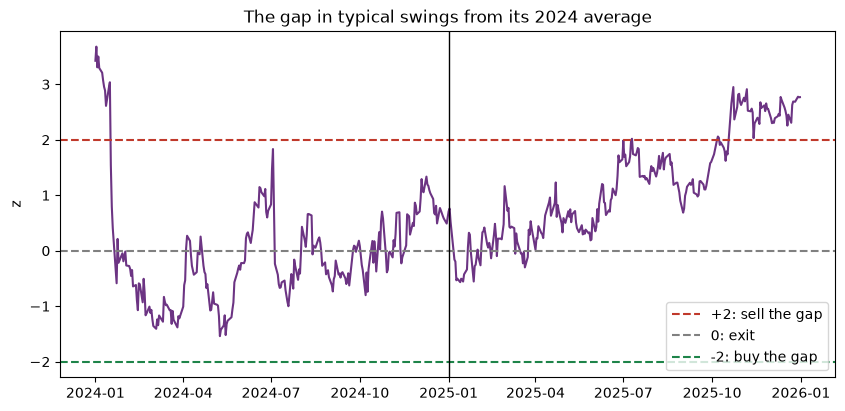

In [7]:
mu = spread.loc["2024"].mean()
sd = spread.loc["2024"].std()
z = (spread - mu) / sd

plt.figure(figsize=(10, 4.5))
plt.plot(z.loc["2024":], color="#6C3483")
plt.axhline(2, color="#C0392B", linestyle="--", label="+2: sell the gap")
plt.axhline(0, color="grey", linestyle="--", label="0: exit")
plt.axhline(-2, color="#1E8449", linestyle="--", label="-2: buy the gap")
plt.axvline(pd.Timestamp("2025-01-01"), color="black", linewidth=1)
plt.ylabel("z")
plt.title("The gap in typical swings from its 2024 average")
plt.legend()
plt.show()

## Step 6 — the trading rule

- z **above +2**: the gap is too wide. **Sell the gap**: sell 1 HDFC, buy beta ICICI.
  Position = −1.
- z **below −2**: the gap is too narrow. **Buy the gap**. Position = +1.
- z **back to 0**: the gap is normal again. **Exit**. Position = 0.

A loop walks through the days one at a time, exactly like a backtest should.

In [8]:
def pair_positions(z, period, entry=2.0):
    position = pd.Series(0.0, index=z.index)
    current = 0
    for day in z.loc[period].index:
        if current == 0 and z[day] > entry:
            current = -1                     # sell the gap
        elif current == 0 and z[day] < -entry:
            current = 1                      # buy the gap
        elif (current == 1 and z[day] >= 0) or (current == -1 and z[day] <= 0):
            current = 0                      # back to normal: exit
        position[day] = current
    return position.loc[period]

for period in ["2024", "2025"]:
    pos = pair_positions(z, period)
    changes = pos[pos.diff().fillna(pos) != 0]
    print(period, "entries and exits:")
    print(changes.to_string() if len(changes) else "  none")
    print()

2024 entries and exits:
Date
2024-01-01   -1.0
2024-01-23    0.0

2025 entries and exits:
Date
2025-07-10   -1.0



## Step 7 — what did it earn?

Holding the gap earns the day's change in the gap: position (held from yesterday) ×
change in gap. That is profit in rupees **per HDFC share** in the pair. We also charge
0.1% of the two legs' value whenever the position changes.

In [9]:
def pair_profit(period):
    pos = pair_positions(z, period)
    gross = (pos.shift(1) * spread.diff().loc[period]).sum()
    legs_value = (hdfc + beta * icici).loc[period]              # money in both legs
    cost = (0.001 * pos.diff().abs() * legs_value).sum()
    return gross, cost, pos.iloc[-1]

for period, label in [("2024", "2024, fitted on"), ("2025", "2025, fresh data")]:
    gross, cost, last = pair_profit(period)
    p = coint(prices.loc[period, "HDFCBANK"], prices.loc[period, "ICICIBANK"])[1]
    print(f"{label:17s} leash p-value {p:.3f}   profit before costs Rs {gross:7.1f}"
          f"   costs Rs {cost:5.1f}   still open at year end: {last != 0}")

2024, fitted on   leash p-value 0.024   profit before costs Rs   144.7   costs Rs   1.2   still open at year end: False
2025, fresh data  leash p-value 0.778   profit before costs Rs   -27.1   costs Rs   1.7   still open at year end: True


## Step 8 — read it honestly

On 2024, the year we fitted on, the rule caught a big stretched gap in January and made
money. But that is in-sample: the average and the swing were computed from the same
year, so it had seen the answers.

On 2025, the fresh year, the leash snapped. The p-value jumps far above 0.05, the gap
drifted up and stayed up, and the rule sold the gap in July and was still waiting at the
end of the year, down money. A backtest that only showed 2024 would have looked like a
money machine.

### Stretch (optional) — a rolling re-fit

Skip unless curious. Instead of one fixed 2024 average, recompute the average and swing
every day from the previous 120 days only (`.rolling(120)` then `.shift(1)`, so there is
no look-ahead). Does the rule do better in 2025? What new risk does re-fitting bring?

In [10]:
roll_mu = spread.rolling(120).mean().shift(1)
roll_sd = spread.rolling(120).std().shift(1)
z_roll = (spread - roll_mu) / roll_sd

pos_roll = pair_positions(z_roll, "2025")
gross_roll = (pos_roll.shift(1) * spread.diff().loc["2025"]).sum()
print("2025 with a rolling 120-day fit: profit before costs Rs", round(gross_roll, 1),
      "  trades:", int(pos_roll.diff().abs().fillna(0).gt(0).sum()))

2025 with a rolling 120-day fit: profit before costs Rs 82.1   trades: 7


## Your turn

Pick another pair that should move together and repeat Steps 3 to 7: fit on 2024,
trade 2025. Download the prices with yfinance, for example two IT companies
(`"TCS.NS"`, `"INFY.NS"`) or two cement makers (`"ULTRACEMCO.NS"`, `"SHREECEM.NS"`).
Report the leash test, the profit after costs, and two sentences on whether you would
trust it.

In [11]:
# Your code here, for example:
# import yfinance as yf
# pair = yf.download(["TCS.NS", "INFY.NS"], start="2024-01-01", end="2026-01-01",
#                    auto_adjust=True, progress=False)["Close"]

## What you just did

You built the gap between two banks, tested the leash before trusting it, turned the gap
into a z-score, traded it with a three-line rule, and judged it on a year it had never
seen, after costs. The honest answer was that the pair broke. That is exactly what an
honest backtest is for: finding out before real money does.